## 1. Import libraries & packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

## 2. Load the dataset into a dataframe

In [2]:
df=pd.read_csv('data/raw/train.csv')
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 3. BiVariate Analysis

#### 3.1 Plot the relation between Tyre Compound & PitNextLap

<Axes: xlabel='Compound', ylabel='count'>

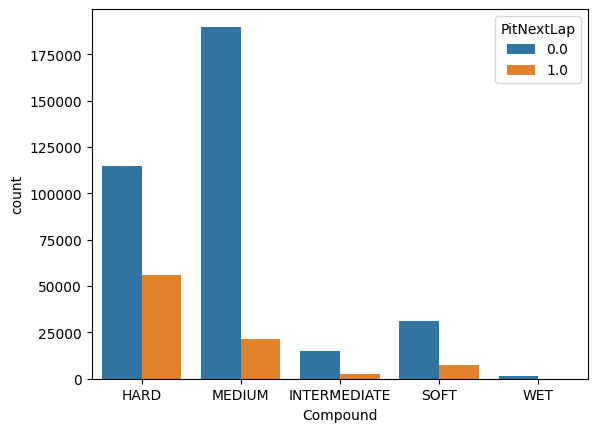

In [3]:
sb.countplot(data=df, x='Compound', hue='PitNextLap')

Counplot gives us a vague idea of data distribution but since i am trying to plot the relation between two categorical columns, I shall plot the distribution of proportions and normalize it in the same scale.

Text(0.5, 1.0, 'Intensity of realtionships')

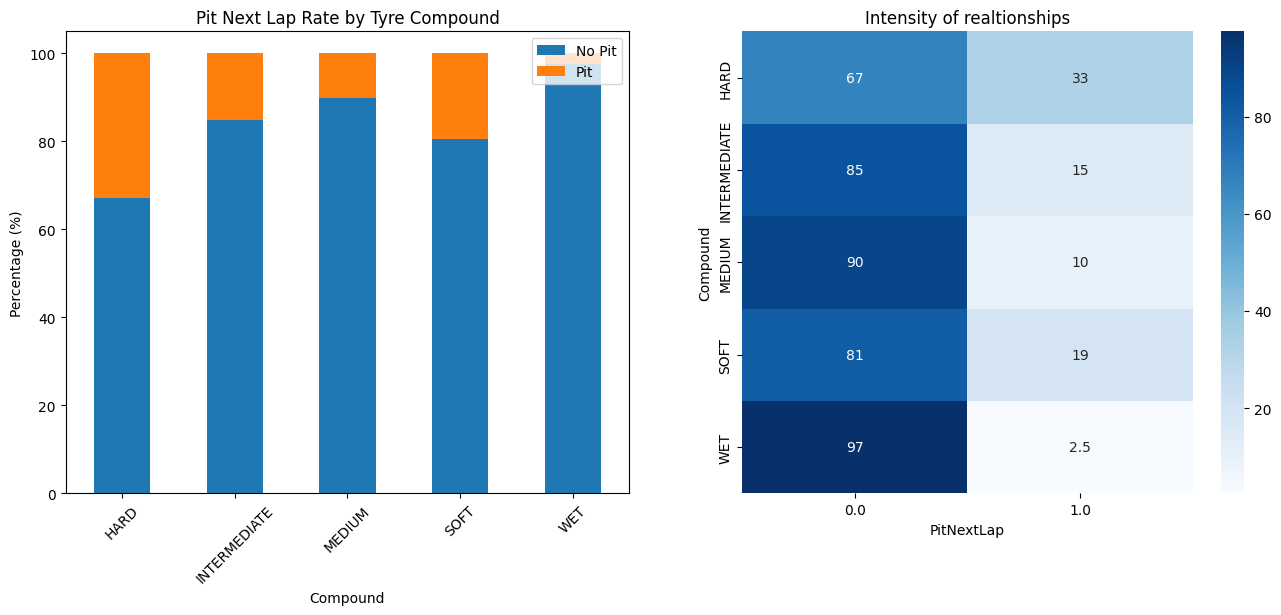

In [4]:
# Proportional grouped bar
fig, axes = plt.subplots(1,2, figsize=(16,6))

ct = pd.crosstab(df['Compound'], df['PitNextLap'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Pit Next Lap Rate by Tyre Compound')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['No Pit', 'Pit'], loc='upper right')

sb.heatmap(ct,annot=True,cmap='Blues',ax=axes[1])
axes[1].set_title("Intensity of realtionships")

Observations:
1. The HARD compound tires have more pit next lap rate as roughly 35% of F1 players running with HARD tire compounds performed a pit.
2. The players running with INTERMEDIATE & SOFT tire compounds have roughly same pit rate with SOFT tire compounds leading by just a small margin, indicating that SOFT tire compounds wear away slightly early than intermediate ones which is correct.
3. The MEDIUM compound tires performed well according to the expectations from it. It has lower pit rate than INTERMEDIATE & SOFT tires but higher than WET tires.
4. The WET tire compound has the lowest pit rate among all compounds, possibly due to wet track or weather conditions which allowed the driver to cover more laps before requiring any pit.

<Axes: xlabel='Year', ylabel='count'>

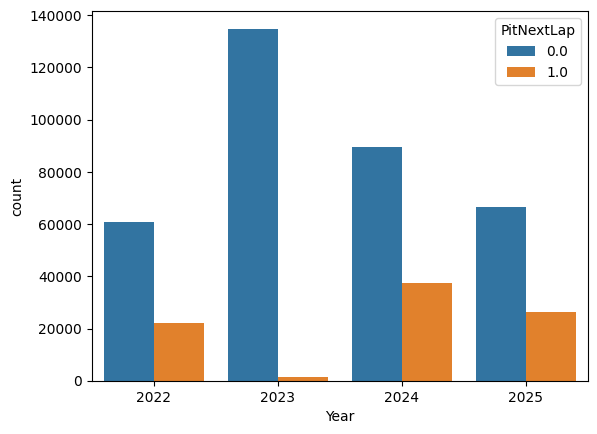

In [5]:
sb.countplot(data=df,x='Year',hue='PitNextLap')

Text(0.5, 0, 'Year')

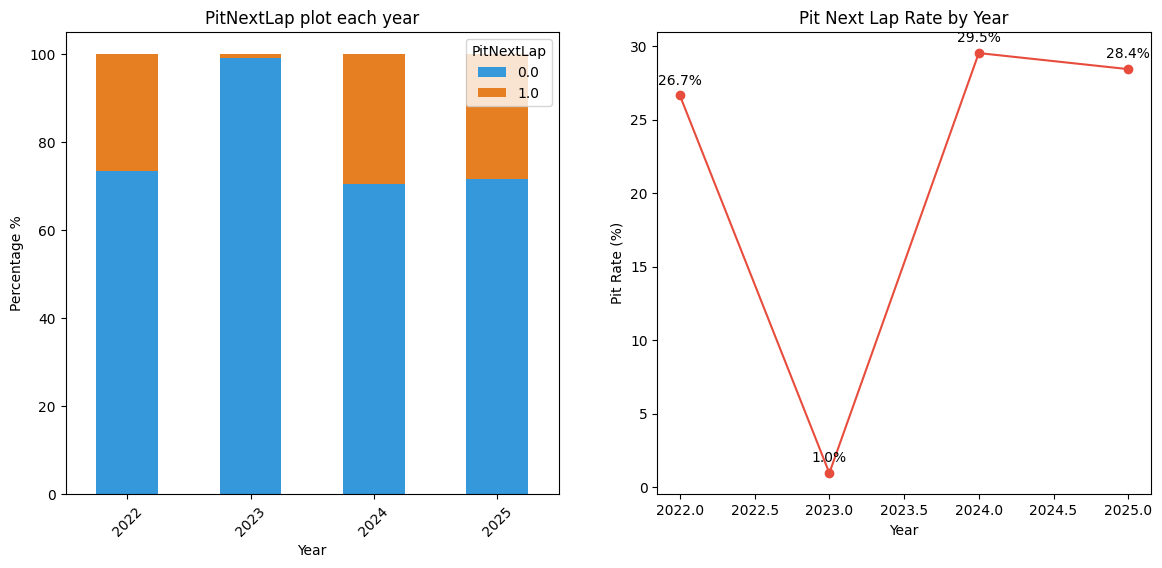

In [6]:
fig, axes = plt.subplots(1,2,figsize=(14,6))

ct = pd.crosstab(df['Year'], df['PitNextLap'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, color=['#3498db', '#e67e22'], ax=axes[0])
axes[0].set_title("PitNextLap plot each year")
axes[0].set_ylabel("Percentage %")
axes[0].set_xlabel("Year")
axes[0].tick_params(axis='x',rotation=45)

pit_rate = df.groupby('Year')['PitNextLap'].mean() * 100

for x,y in (zip(pit_rate.index,pit_rate.values)):
    axes[1].annotate(f'{y:.1f}%', # print the value
                    (x,y), # where to print the value, provide the co-ordinates
                    textcoords='offset points', # as an offset measured in screen points from the marker.
                    xytext=(0,8),
                    ha='center')

pit_rate.plot(kind='line', marker='o', color='#e74c3c',ax=axes[1])
axes[1].set_ylabel('Pit Rate (%)')
axes[1].set_title('Pit Next Lap Rate by Year')
axes[1].set_xlabel("Year")

Observations:
1. The pit next lap rate has been almost consistent from the year 2022 to 2025 except just one year; 2023.
2. Year 2023 has the lowest pit rate among all 4 years of data, possibly due to policy changes in f1 race or due to drivers following a particular strategy of less pitting

In [7]:
df['Year'].value_counts()

Year
2023    136147
2024    127110
2025     92894
2022     82989
Name: count, dtype: int64

<Axes: xlabel='PitStop', ylabel='count'>

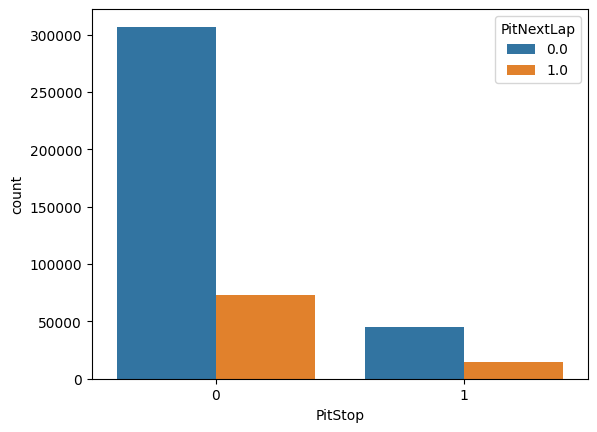

In [8]:
sb.countplot(data=df,x='PitStop',hue='PitNextLap')

[Text(0.5, 0, 'No PitNextLap'), Text(1.5, 0, 'PitNextLap')]

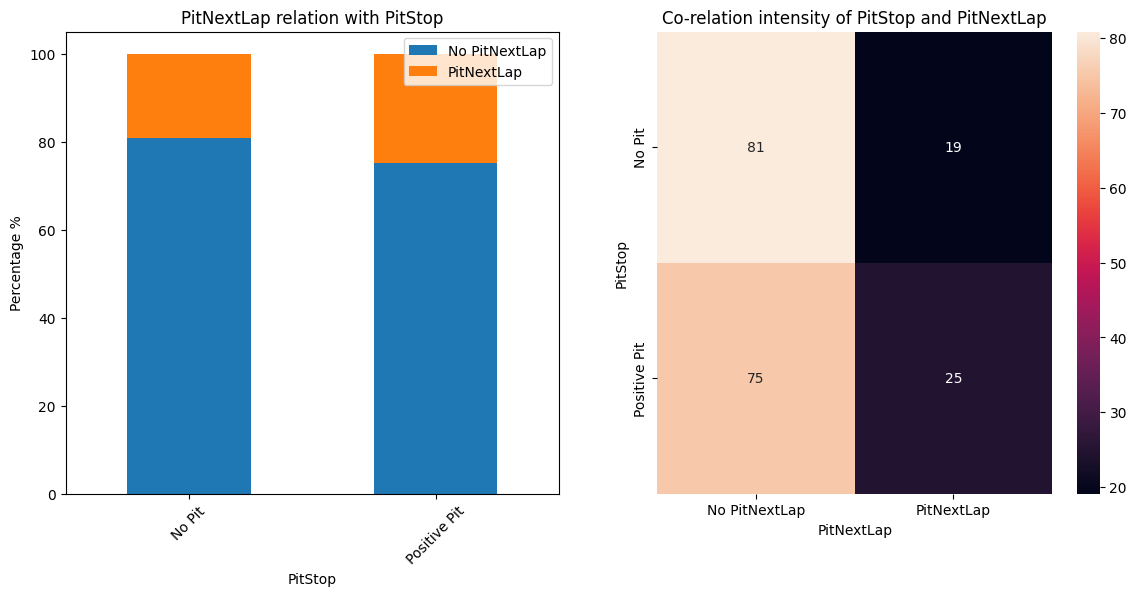

In [9]:
fig, axes = plt.subplots(1,2,figsize=(14,6))

cross_tab = pd.crosstab(df['PitStop'],df['PitNextLap'],normalize='index') * 100
cross_tab.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title("PitNextLap relation with PitStop")
axes[0].set_ylabel("Percentage %")
axes[0].set_xticklabels(['No Pit','Positive Pit'])
axes[0].tick_params(axis='x',rotation=45)
axes[0].legend(['No PitNextLap', 'PitNextLap'], loc='upper right')

sb.heatmap(cross_tab,annot=True,ax=axes[1])
axes[1].set_title("Co-relation intensity of PitStop and PitNextLap")
axes[1].set_yticklabels(['No Pit','Positive Pit'])
axes[1].set_xticklabels(['No PitNextLap','PitNextLap'])


Observations:
1. It can be observed from both the graphs that, the chances of pitting reduces slightly when the driver doesn't perform a pit stop in the current lap.
2. Also the positive pitting in the current lap , only slightly increases the chances from 19% to 25% that the driver will perform the Pit in the next lap.

Therefore, there isn't a strong co-relation between the two attributes that can be a standalone factor in deriving out conclusions from it

In [10]:
df.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='str')

In Formula 1, a STINT signifies the continuous period a car spends on track between leaving the pit lane (or starting the race) and its next pit stop. The stint number simply tracks how many of these intervals a driver has completed in a race.

Text(0.5, 1.0, 'Percentage of Stint with respect to PitNextLap')

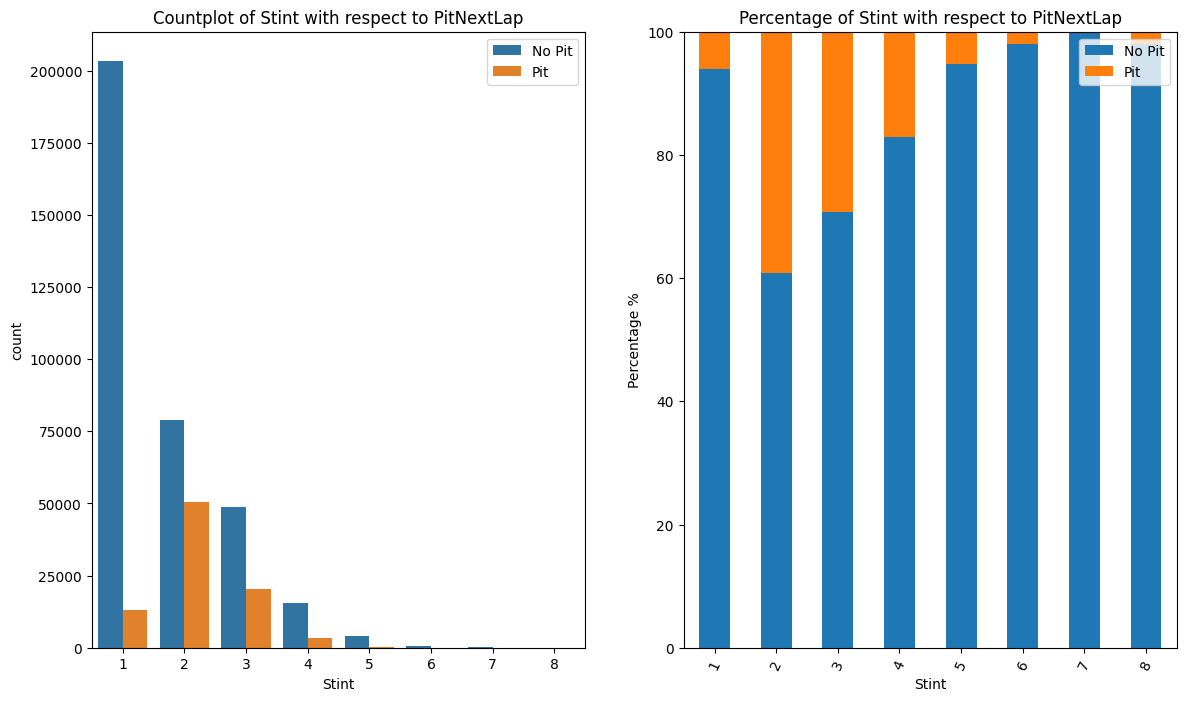

In [11]:
fig, axes = plt.subplots(1,2,figsize=(14,8))
fig
sb.countplot(data=df,x='Stint',hue='PitNextLap',ax=axes[0])
axes[0].set_title("Countplot of Stint with respect to PitNextLap")
axes[0].legend(['No Pit','Pit'])

ct= pd.crosstab(df['Stint'],df['PitNextLap'],normalize='index') * 100
#normalize the values means, dividing the class occurence by total number of total class

ct.plot(kind='bar',stacked=True,ax=axes[1])
axes[1].legend(['No Pit','Pit'],loc='upper right')
axes[1].set_ylabel("Percentage %")
axes[1].tick_params(axis='x',rotation=65)
axes[1].set_title("Percentage of Stint with respect to PitNextLap")

A stint is your current fuel and tyres. A new stint is started by a pitstop. 2 stints will mean 1 pitstop, 3 stints will require 2 pitstops and so on.

Observations:
1. It can be clearly observed from the graph that during the initial Stint (1) , only 20% of the drivers performed the Pit Stop i.e. just after one lap of the beginning of the race.
2. As the race proceeds, 60% of the drivers didn't pit while 40% of them pit in Stint (2)
3. At Stint (3), only 70% of the drivers didn't pit, while 30% of them pit.

Therefore, it can be clearly concluded that as the stint increases, the pit rate decreases with some exception in stint 8. Possibly there are some outliers, will check in different plot. 

In [12]:
df['Stint'].nunique()

8

In [14]:
df.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='str')

Numerical feature vs categorical target

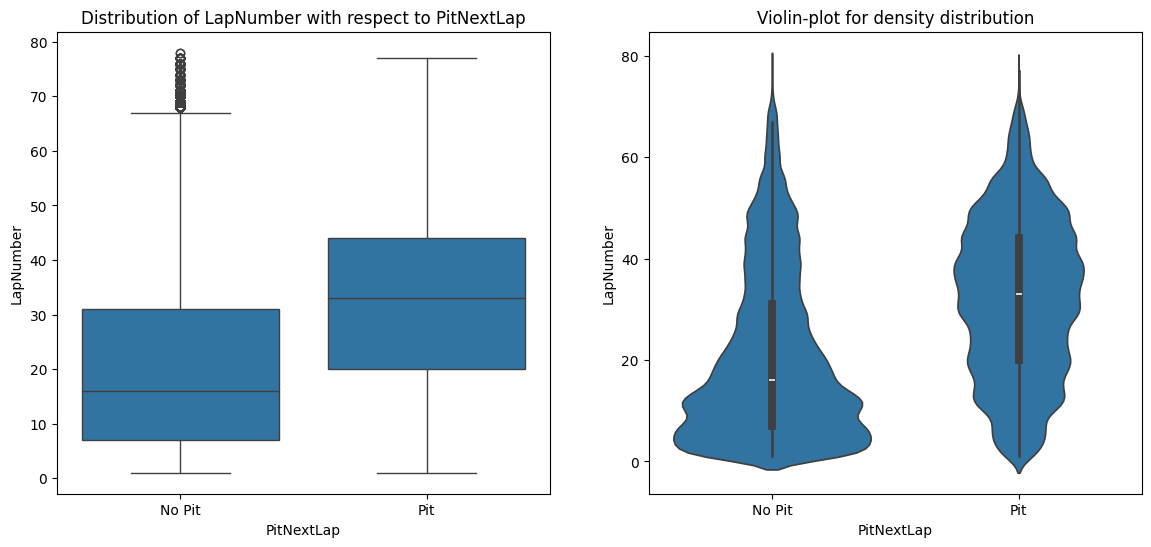

In [24]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

sb.boxplot(data=df,x='PitNextLap',y='LapNumber',ax=axes[0])
axes[0].set_title("Distribution of LapNumber with respect to PitNextLap")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No Pit","Pit"])

sb.violinplot(data=df,x="PitNextLap",y="LapNumber",ax=axes[1])
axes[1].set_title("Violin-plot for density distribution")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()
